In [2]:
import pandas as pd

prices = pd.read_parquet("../phase2/clean_prices_50_assets.parquet")
prices = prices.reset_index()

print(prices.head())
print(prices.columns)


Price        Date  Adj Close                                                \
Ticker                  AAPL        AMD       AMZN     ASML.AS        BABA   
0      2018-07-26  45.801083  18.350000  90.400002  172.443085  184.411774   
1      2018-07-27  45.039349  18.940001  90.863503  173.094833  179.891235   
2      2018-07-30  44.787003  19.420000  88.960999  171.418823  175.522644   
3      2018-07-31  44.876602  18.330000  88.872002  170.860168  177.811386   
4      2018-08-01  47.520306  18.480000  89.858498  171.092941  175.949997   

Price                                                 ...     Volume  \
Ticker        BAC       BRK-B        COP        COST  ...     SIE.DE   
0       25.694672  197.460007  55.724453  199.493469  ...  2899906.0   
1       25.794331  197.949997  55.452797  197.631027  ...  2090429.0   
2       26.001947  199.089996  56.089184  197.145203  ...  1224903.0   
3       25.644846  197.869995  56.011578  196.785263  ...  2013498.0   
4       25.952118  19

CONVERTING DATASET TO LONG

In [3]:
date_col = prices[("Date", "")]

adj = prices.xs("Adj Close", level=0, axis=1).copy()
high = prices.xs("High", level=0, axis=1).copy()
low = prices.xs("Low", level=0, axis=1).copy()
volume = prices.xs("Volume", level=0, axis=1).copy()

adj["Date"] = date_col.values
high["Date"] = date_col.values
low["Date"] = date_col.values
volume["Date"] = date_col.values

adj_long = adj.melt(id_vars="Date", var_name="ticker", value_name="adj_close")
high_long = high.melt(id_vars="Date", var_name="ticker", value_name="high")
low_long = low.melt(id_vars="Date", var_name="ticker", value_name="low")
volume_long = volume.melt(id_vars="Date", var_name="ticker", value_name="volume")

df = (
    adj_long
    .merge(high_long, on=["Date", "ticker"])
    .merge(low_long, on=["Date", "ticker"])
    .merge(volume_long, on=["Date", "ticker"])
    .rename(columns={"Date": "date"})
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

print(df.head())
print(df.columns)

        date ticker  adj_close       high        low       volume
0 2018-07-26   AAPL  45.801083  48.990002  48.402500   76304000.0
1 2018-07-27   AAPL  45.039349  48.797501  47.525002   96096000.0
2 2018-07-30   AAPL  44.787003  48.049999  47.267502   84118000.0
3 2018-07-31   AAPL  44.876602  48.035000  47.334999  157492000.0
4 2018-08-01   AAPL  47.520306  50.439999  49.327499  271742800.0
Index(['date', 'ticker', 'adj_close', 'high', 'low', 'volume'], dtype='object')


RSI FEATURE

In [4]:
def compute_rsi(series, window = 14):
    delta = series.diff()

    gain = delta.clip(lower = 0)
    loss = -delta.clip(upper = 0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs= avg_gain/avg_loss
    rsi = 100-(100/1+rs)
    return rsi

TREND FEATURES

In [5]:
df["daily_return"] = df.groupby("ticker")["adj_close"].pct_change()
df["ma_20"] = df.groupby("ticker")["adj_close"].transform(lambda s: s.rolling(20).mean())
df["ma_50"] = df.groupby("ticker")["adj_close"].transform(lambda s: s.rolling(50).mean())
df["ma20_ma50_ratio"] = df["ma_20"] / df["ma_50"]
df["distance_to_ma20"] = (df["adj_close"] - df["ma_20"]) / df["ma_20"]
df["rolling_20d_return"] = df.groupby("ticker")["adj_close"].pct_change(20)



RSI

In [6]:
df["rsi_14"] = df.groupby("ticker")["adj_close"].transform(compute_rsi)

MACD

In [7]:
df["macd_12_26_9"] = df.groupby("ticker")["adj_close"].transform(
    lambda s: s.ewm(span=12, adjust=False).mean() - s.ewm(span=26, adjust=False).mean()
)
df["macd_signal"] = df.groupby("ticker")["macd_12_26_9"].transform(
    lambda s: s.ewm(span=9, adjust=False).mean()
)
df["macd_histogram"] = df["macd_12_26_9"] - df["macd_signal"]

VOLATILITY FEATURES

In [8]:
df["vol_20"] = df.groupby("ticker")["daily_return"].transform(lambda s: s.rolling(20).std())


ATR

In [9]:
prev_close = df.groupby("ticker")["adj_close"].shift(1)
tr1 = df["high"] - df["low"]
tr2 = (df["high"] - prev_close).abs()
tr3 = (df["low"] - prev_close).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
df["atr_14"] = true_range.groupby(df["ticker"]).transform(lambda s: s.rolling(14).mean())

BOLLINGER

In [10]:
std20_price = df.groupby("ticker")["adj_close"].transform(lambda s: s.rolling(20).std())
upper = df["ma_20"] + 2 * std20_price
lower = df["ma_20"] - 2 * std20_price
df["bollinger_pct_b"] = (df["adj_close"] - lower) / (upper - lower)
df["bollinger_width"] = (upper - lower) / df["ma_20"]

VOLUME Z-SCORE

In [11]:
vol_mean_20 = df.groupby("ticker")["volume"].transform(lambda s: s.rolling(20).mean())
vol_std_20 = df.groupby("ticker")["volume"].transform(lambda s: s.rolling(20).std())
df["volume_zscore_20"] = (df["volume"] - vol_mean_20) / vol_std_20

FINALIZING AND QUALITY CHECKS

In [12]:
df = df.rename(columns={"daily_return": "return"})

In [13]:
final_cols = [
    "date",
    "ticker",
    "return",
    "ma_20",
    "ma_50",
    "ma20_ma50_ratio",
    "distance_to_ma20",
    "rolling_20d_return",
    "rsi_14",
    "macd_12_26_9",
    "macd_histogram",
    "vol_20",
    "atr_14",
    "bollinger_pct_b",
    "bollinger_width",
    "volume_zscore_20"
]

In [14]:
final_df = df[final_cols].dropna().copy()

In [15]:
final_df.head()

,date,ticker,return,ma_20,ma_50,ma20_ma50_ratio,distance_to_ma20,rolling_20d_return,rsi_14,macd_12_26_9,macd_histogram,vol_20,atr_14,bollinger_pct_b,bollinger_width,volume_zscore_20
49,2018-10-09,AAPL,0.011503,52.721424,51.172302,1.030273,0.018391,0.025169,-1.984656,0.658260,0.007534,0.014203,3.639341,0.772799,0.067415,-0.463602
50,2018-10-10,AAPL,-0.046326,52.698113,51.280355,1.027647,-0.028358,-0.009023,-0.904276,0.450856,-0.159896,0.017521,3.567729,0.095253,0.070062,0.464224
51,2018-10-11,AAPL,-0.008828,52.586884,51.394602,1.023199,-0.034898,-0.041992,-0.818099,0.247164,-0.290870,0.016531,3.597367,0.048878,0.077358,1.064316
52,2018-10-12,AAPL,0.035719,52.599190,51.550153,1.020350,-0.000659,0.004705,-1.096521,0.229371,-0.246930,0.018341,3.674346,0.491462,0.077193,0.330697
53,2018-10-15,AAPL,-0.021386,52.492101,51.681428,1.015686,-0.020036,-0.039972,-0.987460,0.123142,-0.282528,0.018061,3.647577,0.241942,0.077641,-0.218202


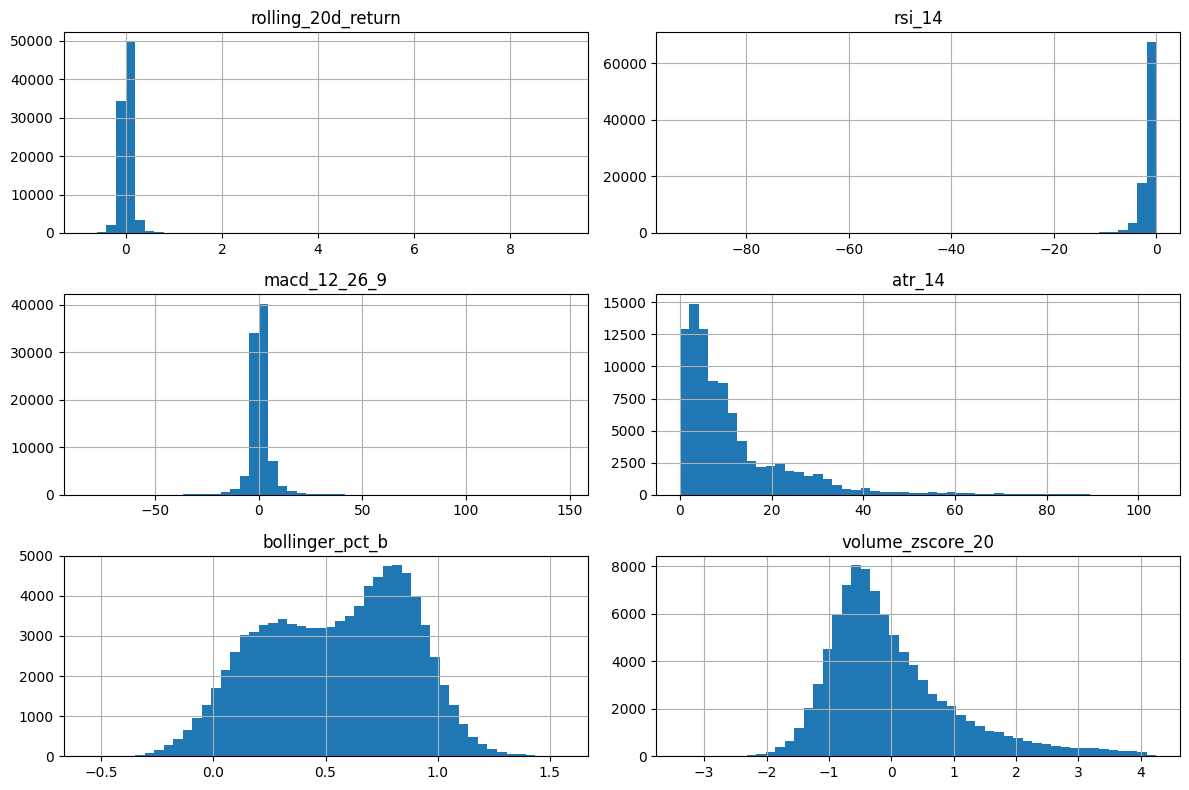

In [16]:
import matplotlib.pyplot as plt
import numpy as np

cols = [
    "rolling_20d_return",
    "rsi_14",
    "macd_12_26_9",
    "atr_14",
    "bollinger_pct_b",
    "volume_zscore_20"
]

# Filter out infinite values before plotting
for col in cols:
    # Replace inf and -inf with NaN
    final_df[col] = final_df[col].replace([np.inf, -np.inf], np.nan)


final_df[cols].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [17]:
final_df = final_df.dropna().copy()

In [18]:
df = df.sort_values(["ticker", "date"])

In [19]:
final_df.isna().sum()

date                  0
ticker                0
return                0
ma_20                 0
ma_50                 0
ma20_ma50_ratio       0
distance_to_ma20      0
rolling_20d_return    0
rsi_14                0
macd_12_26_9          0
macd_histogram        0
vol_20                0
atr_14                0
bollinger_pct_b       0
bollinger_width       0
volume_zscore_20      0
dtype: int64

In [20]:
final_df[cols].nunique()

rolling_20d_return    90470
rsi_14                90380
macd_12_26_9          90733
atr_14                89493
bollinger_pct_b       90720
volume_zscore_20      90676
dtype: int64

In [21]:
print(final_df["date"].min(), final_df["date"].max())

2018-10-09 00:00:00 2026-04-02 00:00:00


In [24]:
final_df.to_parquet("advanced_technical_features.parquet")